# Lab 12 — Frontiers: Delay-Doppler Waveforms, ISAC and Learned Receivers

**Companion to Chapter 12.** Three self-contained experiments:

1. **OTFS vs OFDM** on a doubly-dispersive channel: why Doppler breaks OFDM's
   one-tap equalizer and how delay-Doppler modulation recovers diversity.
2. **OFDM radar (ISAC):** turn the communication waveform into a range-velocity
   sensor with two FFTs.
3. **A learned demapper:** train a small neural network (pure NumPy) to detect
   16-QAM through a nonlinear power amplifier with phase noise.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider
import commlib as cl

cl.style()
rng = np.random.default_rng(12)
qpsk = cl.get_constellation("qpsk")

## 1. The doubly-dispersive channel
A channel with $P$ paths, each with delay $\ell_p$ (samples) and Doppler
$\nu_p$ (cycles per sample), acts on the transmitted samples as
$r[n] = \sum_p h_p\, e^{j2\pi \nu_p n}\, s[n-\ell_p] + w[n]$.
In OFDM, the Doppler term spreads energy from each subcarrier into its
neighbours (inter-carrier interference, ICI) once $\nu_{\max}$ is a noticeable
fraction of the subcarrier spacing.

**OTFS** places QAM symbols on an $M\times N$ delay-Doppler grid and maps them
to time via the inverse symplectic FFT. With rectangular pulses and one CP per
frame this is $s = \mathrm{vec}(X_{DD} F_N^H)$: each Doppler bin becomes a
frame-length complex exponential. Every symbol then experiences *every* path,
and the effective channel in the DD domain is sparse and nearly
time-invariant. We detect with LMMSE on the full effective channel.

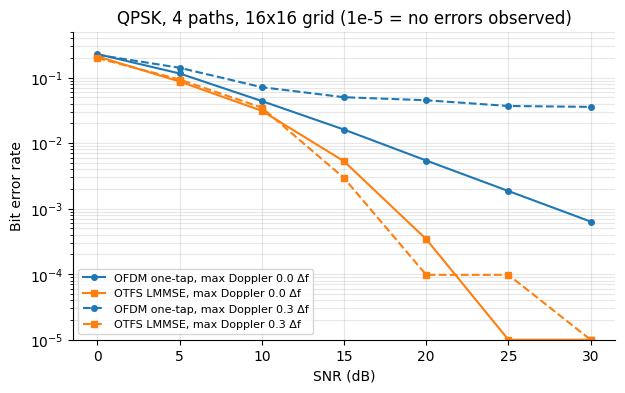

In [3]:
M, N = 16, 16                        # delay bins (subcarriers) x Doppler bins (symbols)
MN = M * N
FN = np.fft.fft(np.eye(N)) / np.sqrt(N)
FM = np.fft.fft(np.eye(M)) / np.sqrt(M)

def paths(n_paths, max_delay, nu_max, rng):
    """Random paths; Doppler in units of the OFDM subcarrier spacing (1/M cycles/sample)."""
    l = np.sort(rng.integers(0, max_delay + 1, n_paths)); l[0] = 0
    nu = rng.uniform(-nu_max, nu_max, n_paths) / M        # cycles/sample
    h = (rng.standard_normal(n_paths) + 1j * rng.standard_normal(n_paths)) / np.sqrt(2 * n_paths)
    return l, nu, h

def channel_matrix(l, nu, h, L):
    """Time-domain channel on an L-sample block with a cyclic prefix (circular delays)."""
    n = np.arange(L)
    H = np.zeros((L, L), dtype=complex)
    for lp, vp, hp in zip(l, nu, h):
        H += hp * np.diag(np.exp(2j * np.pi * vp * n)) @ np.roll(np.eye(L), lp, axis=0)
    return H

A_otfs = np.kron(FN.conj().T, np.eye(M))      # vec(X F_N^H) for column-major vec, X is M x N

def otfs_ber(snr_db, nu_max, trials=40, n_paths=4, max_delay=3):
    errs = bits = 0
    n0 = 10 ** (-snr_db / 10)
    for _ in range(trials):
        l, nu, h = paths(n_paths, max_delay, nu_max, rng)
        Heff = A_otfs.conj().T @ channel_matrix(l, nu, h, MN) @ A_otfs
        b = cl.random_bits(2 * MN, rng); x = qpsk.modulate(b)
        y = Heff @ x + np.sqrt(n0 / 2) * (rng.standard_normal(MN) + 1j * rng.standard_normal(MN))
        xh = np.linalg.solve(Heff.conj().T @ Heff + n0 * np.eye(MN), Heff.conj().T @ y)
        errs += np.sum(qpsk.demodulate(xh) != b); bits += len(b)
    return errs / bits

def ofdm_ber(snr_db, nu_max, trials=40, n_paths=4, max_delay=3, cp=4):
    """N OFDM symbols of M subcarriers, per-symbol CP, one-tap ZF with the symbol-average channel."""
    errs = bits = 0
    n0 = 10 ** (-snr_db / 10)
    L = M + cp
    for _ in range(trials):
        l, nu, h = paths(n_paths, max_delay, nu_max, rng)
        b = cl.random_bits(2 * MN, rng); X = qpsk.modulate(b).reshape(N, M)
        s = np.fft.ifft(X, axis=1) * np.sqrt(M)
        s = np.concatenate([s[:, -cp:], s], axis=1).ravel()
        n = np.arange(len(s))
        r = np.zeros(len(s), dtype=complex)
        for lp, vp, hp in zip(l, nu, h):
            r += hp * np.exp(2j * np.pi * vp * n) * np.roll(s, lp)
        r += np.sqrt(n0 / 2) * (rng.standard_normal(len(r)) + 1j * rng.standard_normal(len(r)))
        Y = np.fft.fft(r.reshape(N, L)[:, cp:], axis=1) / np.sqrt(M)
        k = np.arange(M)
        mid = np.arange(N)[:, None] * L + cp + M / 2
        Hk = sum(hp * np.exp(2j * np.pi * vp * mid) * np.exp(-2j * np.pi * k * lp / M)
                 for lp, vp, hp in zip(l, nu, h))
        errs += np.sum(qpsk.demodulate((Y / Hk).ravel()) != b); bits += len(b)
    return errs / bits

snrs = np.arange(0, 31, 5)
fig, ax = plt.subplots(figsize=(7, 4))
for nu_max, st in [(0.0, "-"), (0.3, "--")]:
    ax.semilogy(snrs, [max(ofdm_ber(s, nu_max), 1e-5) for s in snrs], "C0" + st + "o", ms=4,
                label=f"OFDM one-tap, max Doppler {nu_max} Δf")
    ax.semilogy(snrs, [max(otfs_ber(s, nu_max), 1e-5) for s in snrs], "C1" + st + "s", ms=4,
                label=f"OTFS LMMSE, max Doppler {nu_max} Δf")
cl.ber_axes(ax, "SNR (dB)"); ax.set_ylim(1e-5, 0.5); ax.legend(fontsize=8)
ax.set_title("QPSK, 4 paths, 16x16 grid (1e-5 = no errors observed)"); plt.show()

Two effects are visible. OFDM with a one-tap equalizer has only single-path
(Rayleigh) diversity, so its curve falls slowly, and under Doppler it hits an
ICI error floor. OTFS with a joint detector harvests delay *and* Doppler
diversity, so its slope is steeper, and Doppler costs it almost nothing.
Fairness note: the OTFS receiver is far more complex (a 256×256 solve here);
an OFDM receiver with full ICI-aware equalization would close part of the gap.
That complexity trade is one reason the 6G study kept CP-OFDM (Chapter 12).

### The delay-Doppler channel is sparse
Below: magnitude of the OTFS effective channel column for one symbol, reshaped
onto the DD grid. Each path appears as a (slightly spread) spike at its delay
and Doppler.

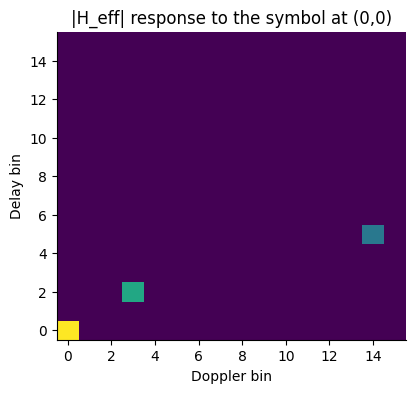

In [5]:
l, nu, h = np.array([0, 2, 5]), np.array([0.0, 3.0, -2.0]) / MN, np.array([1.0, 0.6, 0.4])
Heff = A_otfs.conj().T @ channel_matrix(l, nu, h, MN) @ A_otfs
col = Heff[:, 0].reshape(M, N, order="F")
fig, ax = plt.subplots(figsize=(4.5, 4))
ax.imshow(np.abs(col), origin="lower", aspect="auto"); ax.grid(False)
ax.set_xlabel("Doppler bin"); ax.set_ylabel("Delay bin")
ax.set_title("|H_eff| response to the symbol at (0,0)"); plt.show()

## 2. ISAC: OFDM as a radar
Transmit known OFDM symbols $X[m,n]$ (subcarrier $m$, symbol $n$). A point
target at range $R$ with radial velocity $v$ returns
$Y[m,n] = a\,X[m,n]\,e^{-j2\pi m\Delta f\,2R/c}\,e^{j2\pi n T_s\,2v f_c/c} + W$.
Dividing by $X$ removes the data; an IFFT across subcarriers gives range and an
FFT across symbols gives velocity. Resolution: $\Delta R = c/(2M\Delta f)$,
$\Delta v = \lambda/(2 N T_s)$.

### Interactive: range-Doppler map at 28 GHz, NR numerology μ = 3

range resolution 2.44 m, max range 1250 m, velocity resolution 4.69 m/s, max |v| 300.3 m/s


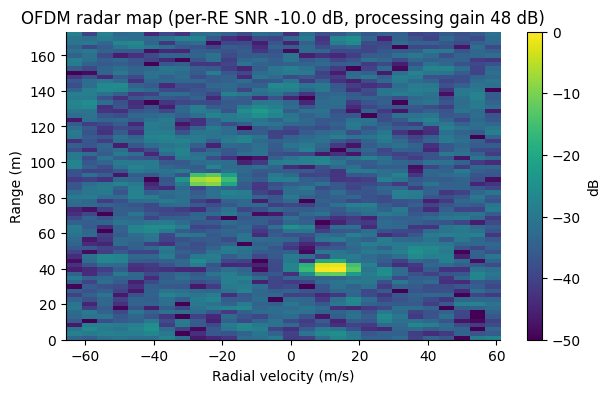

In [7]:
c0, fc = 3e8, 28e9
nr = cl.nr_numerology(3)
df = nr["scs_khz"] * 1e3
Ts = (nr["useful_symbol_us"] + nr["cp_us"]) * 1e-6
Mr, Nr = 512, 128
lam = c0 / fc
print(f"range resolution {c0/(2*Mr*df):.2f} m, max range {c0/(2*df):.0f} m, "
      f"velocity resolution {lam/(2*Nr*Ts):.2f} m/s, max |v| {lam/(4*Ts):.1f} m/s")

def radar(r1=40.0, v1=12.0, r2=90.0, v2=-25.0, snr_db=-10.0):
    X = qpsk.modulate(cl.random_bits(2 * Mr * Nr, rng)).reshape(Mr, Nr)
    m = np.arange(Mr)[:, None]; n = np.arange(Nr)[None, :]
    Y = np.zeros_like(X)
    for R, v, a in [(r1, v1, 1.0), (r2, v2, 0.5)]:
        Y += a * X * np.exp(-2j * np.pi * m * df * 2 * R / c0) * np.exp(2j * np.pi * n * Ts * 2 * v * fc / c0)
    Y += np.sqrt(10 ** (-snr_db / 10) / 2) * (rng.standard_normal(Y.shape) + 1j * rng.standard_normal(Y.shape))
    Z = Y / X
    win = np.hanning(Mr)[:, None] * np.hanning(Nr)[None, :]
    RD = np.fft.fftshift(np.fft.fft(np.fft.ifft(Z * win, axis=0), axis=1), axes=1)
    P = 20 * np.log10(np.abs(RD) + 1e-12); P -= P.max()
    rng_axis = np.arange(Mr) * c0 / (2 * Mr * df)
    vel_axis = (np.arange(Nr) - Nr / 2) * lam / (2 * Nr * Ts)
    fig, ax = plt.subplots(figsize=(7, 4))
    rmax, vw = 72, 14                              # show 0-175 m and +-65 m/s
    im = ax.imshow(P[:rmax, Nr // 2 - vw:Nr // 2 + vw], origin="lower", aspect="auto", vmin=-50, vmax=0,
                   extent=[vel_axis[Nr // 2 - vw], vel_axis[Nr // 2 + vw - 1], 0, rng_axis[rmax - 1]])
    ax.set_xlabel("Radial velocity (m/s)"); ax.set_ylabel("Range (m)"); ax.grid(False)
    ax.set_title(f"OFDM radar map (per-RE SNR {snr_db} dB, processing gain {10*np.log10(Mr*Nr):.0f} dB)")
    plt.colorbar(im, ax=ax, label="dB"); plt.show()

interact(radar, r1=FloatSlider(value=40, min=0, max=160, step=1, description="R1 m"),
         v1=FloatSlider(value=12, min=-40, max=40, step=1, description="v1 m/s"),
         r2=FloatSlider(value=90, min=0, max=160, step=1, description="R2 m"),
         v2=FloatSlider(value=-25, min=-40, max=40, step=1, description="v2 m/s"),
         snr_db=FloatSlider(value=-10, min=-40, max=20, step=2, description="SNR dB"));

## 3. A learned demapper for a nonlinear, phase-noisy transmitter
Model-based detection assumes the received constellation sits on the ideal
grid. A saturated PA (Rapp model) compresses the outer points and phase noise
smears them in angle. A two-layer network trained with cross-entropy learns
the actual decision regions from pilot data. This is the simplest instance of
the "learned receiver" idea studied for 5G-Advanced and 6G (O'Shea & Hoydis,
2017; NVIDIA Sionna provides industrial-strength tooling).

SER at 20.0 dB: minimum-distance 0.0954   learned demapper 0.0094


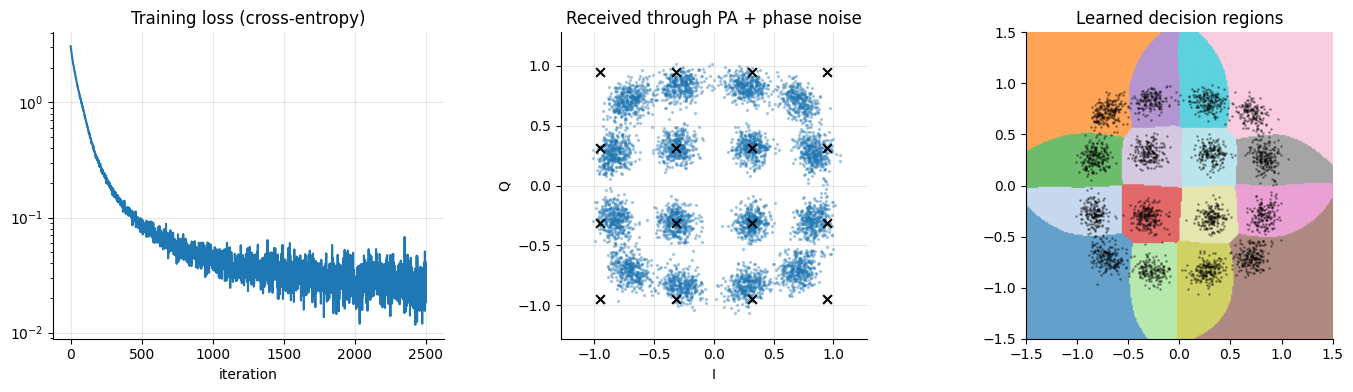

In [9]:
c16 = cl.get_constellation("16qam")

def impaired(idx, snr_db, sat=1.1, pn_deg=4.0):
    x = cl.rapp_pa(c16._lut[idx] * 1.0, sat=sat, p=2.0)
    x *= np.exp(1j * np.deg2rad(pn_deg) * rng.standard_normal(len(x)))
    y, _ = cl.awgn_esn0(x, snr_db, rng=rng, es=1.0)
    return y

def features(y):
    return np.stack([y.real, y.imag, np.abs(y), np.abs(y) ** 2], axis=1)

class MLP:
    def __init__(self, din, dh, dout, rng):
        self.W1 = rng.standard_normal((din, dh)) * np.sqrt(2 / din); self.b1 = np.zeros(dh)
        self.W2 = rng.standard_normal((dh, dout)) * np.sqrt(1 / dh); self.b2 = np.zeros(dout)
        self.params = [self.W1, self.b1, self.W2, self.b2]
        self.m = [np.zeros_like(p) for p in self.params]; self.v = [np.zeros_like(p) for p in self.params]
        self.t = 0
    def forward(self, X):
        self.X = X; self.Z = X @ self.W1 + self.b1; self.Hh = np.maximum(self.Z, 0)
        return self.Hh @ self.W2 + self.b2
    def step(self, logits, labels, lr=3e-3):
        p = np.exp(logits - logits.max(1, keepdims=True)); p /= p.sum(1, keepdims=True)
        g = p.copy(); g[np.arange(len(labels)), labels] -= 1; g /= len(labels)
        gW2 = self.Hh.T @ g; gb2 = g.sum(0)
        gH = g @ self.W2.T * (self.Z > 0)
        gW1 = self.X.T @ gH; gb1 = gH.sum(0)
        self.t += 1
        for i, (prm, gr) in enumerate(zip(self.params, [gW1, gb1, gW2, gb2])):   # Adam
            self.m[i] = 0.9 * self.m[i] + 0.1 * gr; self.v[i] = 0.999 * self.v[i] + 0.001 * gr ** 2
            mh = self.m[i] / (1 - 0.9 ** self.t); vh = self.v[i] / (1 - 0.999 ** self.t)
            prm -= lr * mh / (np.sqrt(vh) + 1e-8)
        return -np.mean(np.log(p[np.arange(len(labels)), labels] + 1e-12))

snr_train = 20.0
net = MLP(4, 64, 16, rng)
losses = []
for it in range(2500):
    idx = rng.integers(0, 16, 512)
    losses.append(net.step(net.forward(features(impaired(idx, snr_train))), idx))

idx = rng.integers(0, 16, 60_000)
y = impaired(idx, snr_train)
ser_std = np.mean(c16.nearest(y) != idx)
ser_nn = np.mean(np.argmax(net.forward(features(y)), 1) != idx)
print(f"SER at {snr_train} dB: minimum-distance {ser_std:.4f}   learned demapper {ser_nn:.4f}")

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].plot(losses); ax[0].set_yscale("log"); ax[0].set_title("Training loss (cross-entropy)"); ax[0].set_xlabel("iteration")
cl.plot_constellation(ax[1], y[:6000], c16.points, "Received through PA + phase noise", s=2)
g = np.linspace(-1.5, 1.5, 250); Xg, Yg = np.meshgrid(g, g)
reg = np.argmax(net.forward(features((Xg + 1j * Yg).ravel())), 1).reshape(Xg.shape)
ax[2].imshow(reg, extent=[-1.5, 1.5, -1.5, 1.5], origin="lower", cmap="tab20", alpha=0.7); ax[2].grid(False)
ax[2].scatter(y[:3000].real, y[:3000].imag, s=1, c="k", alpha=0.3)
ax[2].set_title("Learned decision regions"); plt.tight_layout(); plt.show()

## Exercises

1. **(Warm-up)** Derive the OFDM radar range and velocity resolution formulas
   and the maximum unambiguous range and velocity. Which NR numerology gives
   the best velocity resolution for a fixed 1 ms frame?
2. **(Core)** Add an ICI-aware MMSE equalizer for OFDM (build the full
   per-symbol channel matrix). How much of the OTFS advantage remains?
3. **(Core)** Train the demapper to output bit LLRs (4 sigmoid outputs with
   binary cross-entropy) and measure coded BER with the LDPC code from Lab 9.
4. **(Stretch)** Implement AFDM: replace the OTFS modulation matrix with the
   inverse discrete affine Fourier transform $A^{-1} = \Lambda_{c_1}^H F^H \Lambda_{c_2}^H$,
   choose $c_1$ from the maximum Doppler, and compare BER and PAPR with OTFS.